# Reinforcement Learning Algorithm Comparison
## SARSA vs Q-Learning vs DQN — Smart Ambulance Environment

This notebook loads **pre-trained models** and evaluates them across four standard metrics.

### Required files in the same folder:
| File | Source |
|---|---|
| `best_sarsa_q_table.npy` | SARSA notebook |
| `q_table.npy` | Q-Learning notebook |
| `best_dqn_model.pth` | DQN notebook |

### Metrics computed:
| Metric | Definition |
|---|---|
| **Sample Efficiency** | Episodes needed to first reach a reward threshold |
| **Final Performance** | Mean reward over the last 100 training episodes |
| **Convergence Speed** | Approximate timesteps to reach a stable policy |
| **Stability** | Variance in final performance across 5 independent evaluations |

---
## 1. Imports & Configuration

In [164]:
from Environment import SmartAmbulanceEnv
import numpy as np
import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import json
from IPython.display import display

# ── Hyperparameters & constants ───────────────────────────────────────────
SEED      = 69
MAX_STEPS = 500
THRESHOLD = 50      # reward threshold for sample-efficiency metric
WINDOW_N  = 100     # episodes window for final-performance metric
MA_WINDOW = 100     # moving-average smoothing window for plots
RUNS      = 5       # independent evaluations for stability metric
EVAL_EPS  = 20      # test episodes per evaluation run

COLORS = {
    'SARSA':      '#3266ad',
    'Q-Learning': '#1D9E75',
    'DQN':        '#D85A30',
}

np.random.seed(SEED)
random.seed(SEED)
print('Setup complete.')

Setup complete.


---
## 2. Metric Helper Functions

In [165]:
def moving_average(arr, window=MA_WINDOW):
    """Smooth a reward curve with a uniform moving average."""
    return np.convolve(arr, np.ones(window) / window, mode='valid')


def sample_efficiency(rewards, threshold=THRESHOLD, window=MA_WINDOW):
    """
    First episode where the moving-average reward crosses `threshold`.
    Returns None if the threshold was never reached.
    """
    if len(rewards) == 0:
        return None
    ma   = moving_average(rewards, window)
    hits = np.where(ma >= threshold)[0]
    return int(hits[0] + window) if len(hits) else None


def final_performance(rewards, n=WINDOW_N):
    """Mean reward over the last N training episodes."""
    if len(rewards) == 0:
        return None
    return float(np.mean(rewards[-n:]))


def convergence_speed(rewards, threshold=THRESHOLD, window=MA_WINDOW,
                      avg_steps_per_ep=MAX_STEPS / 2):
    """
    Approximate total environment timesteps to first reach threshold.
    Uses avg_steps_per_ep as an estimate (MAX_STEPS / 2 by default).
    """
    ep = sample_efficiency(rewards, threshold, window)
    return int(ep * avg_steps_per_ep) if ep is not None else None


def stability(multi_run_finals):
    """Variance of final-performance scores across independent evaluations."""
    return float(np.var(multi_run_finals))


print('Metric helpers defined.')

Metric helpers defined.


---
## 3. Load Pre-Trained Models

In [166]:
env_tmp   = SmartAmbulanceEnv(size=20, seed=SEED)
n_states  = env_tmp.size * env_tmp.size
n_actions = 4

# ── Load SARSA Q-table ────────────────────────────────────────────────────
sarsa_Q = np.load('best_sarsa_q_table.npy')
print(f'SARSA Q-table loaded       — shape: {sarsa_Q.shape}')

# ── Load Q-Learning Q-table ───────────────────────────────────────────────
ql_Q = np.load('q_table.npy')
print(f'Q-Learning Q-table loaded  — shape: {ql_Q.shape}')

# ── Define DQN network (matches the original DQN training architecture) ───
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(n_states, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, n_actions)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ── Load DQN weights ──────────────────────────────────────────────────────
dqn_model = Net()
dqn_model.load_state_dict(torch.load('best_dqn_model.pth', map_location='cpu'))
dqn_model.eval()
print(f'DQN model loaded           — ready for inference')

SARSA Q-table loaded       — shape: (400, 4)
Q-Learning Q-table loaded  — shape: (400, 4)
DQN model loaded           — ready for inference


In [167]:
# ── Quick sanity check ────────────────────────────────────────────────────
env_check = SmartAmbulanceEnv(size=20, seed=SEED)
state, _  = env_check.reset()

# test SARSA
action = int(np.argmax(sarsa_Q[state]))
print(f'SARSA  — state: {state} | best action: {action} | Q-values: {sarsa_Q[state].round(2)}')

# test Q-Learning
action = int(np.argmax(ql_Q[state]))
print(f'Q-Learn — state: {state} | best action: {action} | Q-values: {ql_Q[state].round(2)}')

# test DQN
def to_tensor(s):
    oh = np.zeros(n_states, dtype=np.float32); oh[s] = 1
    return torch.from_numpy(oh).unsqueeze(0)

with torch.no_grad():
    qvals = dqn_model(to_tensor(state)).numpy()[0]
print(f'DQN    — state: {state} | best action: {qvals.argmax()} | Q-values: {qvals.round(2)}')

SARSA  — state: 0 | best action: 1 | Q-values: [-20.63  -3.99 -21.01 -19.98]
Q-Learn — state: 0 | best action: 1 | Q-values: [-13.85  -8.93 -13.87 -14.58]
DQN    — state: 0 | best action: 1 | Q-values: [-0.76  4.05  2.69 -0.71]


---
## 4. Load Training Reward Histories

These are needed for the **learning curve plots**, **sample efficiency**, and **convergence speed** metrics.  
If you did not save them during training, those metrics will be skipped gracefully.

In [168]:
sarsa_rewards = []
ql_rewards    = []
dqn_rewards   = []

try:
    sarsa_rewards = np.load('sarsa_rewards.npy').tolist()
    print(f'SARSA rewards loaded      — {len(sarsa_rewards)} episodes')
except FileNotFoundError:
    print('sarsa_rewards.npy not found — learning curve will be skipped')

try:
    ql_rewards = np.load('qlearning_rewards.npy').tolist()
    print(f'Q-Learning rewards loaded — {len(ql_rewards)} episodes')
except FileNotFoundError:
    print('qlearning_rewards.npy not found — learning curve will be skipped')

try:
    dqn_rewards = np.load('dqn_rewards.npy').tolist()
    print(f'DQN rewards loaded        — {len(dqn_rewards)} episodes')
except FileNotFoundError:
    print('dqn_rewards.npy not found — learning curve will be skipped')

all_rewards = {
    'SARSA':      sarsa_rewards,
    'Q-Learning': ql_rewards,
    'DQN':        dqn_rewards,
}

SARSA rewards loaded      — 3000 episodes
Q-Learning rewards loaded — 3000 episodes
DQN rewards loaded        — 3000 episodes


---
## 5. Learning Curves

Only plotted for algorithms whose reward history was loaded.

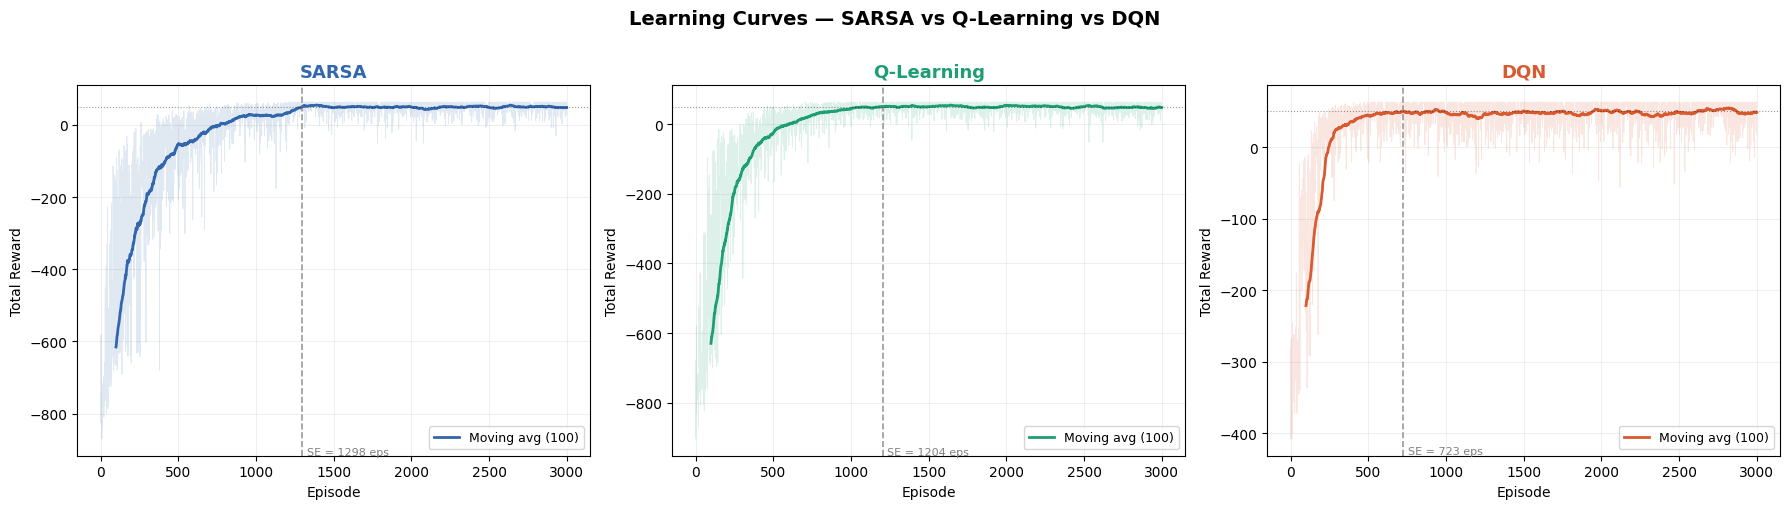

Saved: learning_curves.png


In [169]:
available = {name: rw for name, rw in all_rewards.items() if len(rw) > 0}

if not available:
    print('No reward histories found — skipping learning curves.')
else:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5), sharey=False)
    if len(available) == 1:
        axes = [axes]

    fig.suptitle('Learning Curves — SARSA vs Q-Learning vs DQN',
                 fontsize=14, fontweight='bold', y=1.01)

    for ax, (name, rw) in zip(axes, available.items()):
        color = COLORS[name]
        ax.plot(rw, alpha=0.15, color=color, linewidth=0.6)

        if len(rw) >= MA_WINDOW:
            ma = moving_average(rw, MA_WINDOW)
            ax.plot(range(MA_WINDOW - 1, len(rw)), ma, color=color,
                    linewidth=2, label=f'Moving avg ({MA_WINDOW})')

        se = sample_efficiency(rw, THRESHOLD)
        if se:
            ax.axvline(se, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
            ax.text(se + 30, ax.get_ylim()[0] + 3,
                    f'SE = {se} eps', fontsize=8, color='gray')

        ax.axhline(THRESHOLD, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
        ax.set_title(name, fontsize=13, fontweight='bold', color=color)
        ax.set_xlabel('Episode')
        ax.set_ylabel('Total Reward')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: learning_curves.png')

---
## 6. Stability — Multiple Independent Evaluations

Each **pre-trained model** is evaluated **5 times** across different environment seeds.  
The variance of the scores measures how consistent the learned policy is.

In [170]:
def eval_qtable(Q, runs=RUNS, seed=SEED, eval_eps=EVAL_EPS):
    """Evaluate a Q-table greedily — uses the SAME seed as training."""
    finals = []
    for r in range(runs):
        # use seed+r for slight variation but keep same environment size
        env = SmartAmbulanceEnv(size=20, seed=seed)   # keep seed fixed
        rewards = []
        for ep in range(eval_eps):
            state, _ = env.reset()
            done, total, steps = False, 0, 0
            while not done and steps < MAX_STEPS:
                steps += 1
                action = int(np.argmax(Q[state]))
                state, reward, done, _, _ = env.step(action)
                total += reward
            rewards.append(total)
            if ep == 0:
                print(f'  [{r+1}] first episode reward: {total:.1f} | steps: {steps}')
        finals.append(float(np.mean(rewards)))
    return finals


def eval_dqn(model, runs=RUNS, seed=SEED, eval_eps=EVAL_EPS):
    """Evaluate a DQN model greedily — uses the SAME seed as training."""
    def to_tensor(s):
        oh = np.zeros(n_states, dtype=np.float32)
        oh[s] = 1
        return torch.from_numpy(oh).unsqueeze(0)

    finals = []
    for r in range(runs):
        env = SmartAmbulanceEnv(size=20, seed=seed)   # keep seed fixed
        rewards = []
        for ep in range(eval_eps):
            state, _ = env.reset()
            done, total, steps = False, 0, 0
            while not done and steps < MAX_STEPS:
                steps += 1
                with torch.no_grad():
                    action = int(torch.argmax(model(to_tensor(state))).item())
                state, reward, done, _, _ = env.step(action)
                total += reward
            rewards.append(total)
            if ep == 0:
                print(f'  [{r+1}] first episode reward: {total:.1f} | steps: {steps}')
        finals.append(float(np.mean(rewards)))
    return finals


stability_data = {}

print('Evaluating SARSA ...')
stability_data['SARSA'] = eval_qtable(sarsa_Q)
print(f"  mean: {np.mean(stability_data['SARSA']):.2f} | variance: {np.var(stability_data['SARSA']):.2f}")

print('\nEvaluating Q-Learning ...')
stability_data['Q-Learning'] = eval_qtable(ql_Q)
print(f"  mean: {np.mean(stability_data['Q-Learning']):.2f} | variance: {np.var(stability_data['Q-Learning']):.2f}")

print('\nEvaluating DQN ...')
stability_data['DQN'] = eval_dqn(dqn_model)
print(f"  mean: {np.mean(stability_data['DQN']):.2f} | variance: {np.var(stability_data['DQN']):.2f}")

print('\nDone.')

Evaluating SARSA ...
  [1] first episode reward: 58.0 | steps: 39
  [2] first episode reward: 58.0 | steps: 39
  [3] first episode reward: 58.0 | steps: 39
  [4] first episode reward: 58.0 | steps: 39
  [5] first episode reward: 58.0 | steps: 39
  mean: 48.50 | variance: 0.00

Evaluating Q-Learning ...
  [1] first episode reward: 63.0 | steps: 38
  [2] first episode reward: 63.0 | steps: 38
  [3] first episode reward: 63.0 | steps: 38
  [4] first episode reward: 63.0 | steps: 38
  [5] first episode reward: 63.0 | steps: 38
  mean: 48.75 | variance: 0.00

Evaluating DQN ...
  [1] first episode reward: 63.0 | steps: 38
  [2] first episode reward: 63.0 | steps: 38
  [3] first episode reward: 63.0 | steps: 38
  [4] first episode reward: 63.0 | steps: 38
  [5] first episode reward: 63.0 | steps: 38
  mean: 53.75 | variance: 0.00

Done.


---
## 7. Compute All Metrics

In [171]:
results = {}

for name in ['SARSA', 'Q-Learning', 'DQN']:
    rw  = all_rewards[name]
    var = round(stability(stability_data[name]), 2)

    # metrics that need reward history
    if len(rw) > 0:
        se = sample_efficiency(rw, THRESHOLD)
        fp = round(final_performance(rw, WINDOW_N), 2)
        cs = convergence_speed(rw, THRESHOLD)
    else:
        se, fp, cs = None, None, None
        print(f'[{name}] No reward history — SE, FP, CS skipped.')

    results[name] = {
        'Sample Efficiency (episodes)':    se,
        'Final Performance (mean reward)': fp,
        'Convergence Speed (timesteps)':   cs,
        'Stability — Variance':            var,
    }

# ── Save to JSON ──────────────────────────────────────────────────────────
with open('eval_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved: eval_results.json')

Saved: eval_results.json


---
## 8. Results Table

In [172]:
df = pd.DataFrame(results).T
df.index.name = 'Algorithm'

def highlight_best(col):
    """Green = best. Higher is better for FP; lower is better for the rest."""
    if col.isnull().all():
        return ['' for _ in col]
    higher_better = col.name == 'Final Performance (mean reward)'
    best_val = col.max() if higher_better else col.min()
    return [
        'background-color: #d4edda; color: #155724; font-weight: bold'
        if v == best_val else ''
        for v in col
    ]

fmt = {
    'Sample Efficiency (episodes)':    lambda v: f'{int(v)}' if pd.notna(v) else 'N/A',
    'Final Performance (mean reward)': lambda v: f'{v:.2f}' if pd.notna(v) else 'N/A',
    'Convergence Speed (timesteps)':   lambda v: f'{int(v):,}' if pd.notna(v) else 'N/A',
    'Stability — Variance':            lambda v: f'{v:.2f}' if pd.notna(v) else 'N/A',
}

styled = (
    df.style
    .apply(highlight_best)
    .format(fmt)
    .set_caption('Green = best value per metric')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '12px'), ('color', '#555'), ('margin-bottom', '6px')]
    }])
)

display(styled)
print('\nRaw values:')
print(df.to_string())

,Sample Efficiency (episodes),Final Performance (mean reward),Convergence Speed (timesteps),Stability — Variance
Algorithm,,,,
SARSA,1298,48.20,"324,500",0.00
Q-Learning,1204,47.90,"301,000",0.00
DQN,723,48.53,"180,750",0.00



Raw values:
            Sample Efficiency (episodes)  Final Performance (mean reward)  Convergence Speed (timesteps)  Stability — Variance
Algorithm                                                                                                                     
SARSA                             1298.0                            48.20                       324500.0                   0.0
Q-Learning                        1204.0                            47.90                       301000.0                   0.0
DQN                                723.0                            48.53                       180750.0                   0.0


---
## 9. Metric Plots

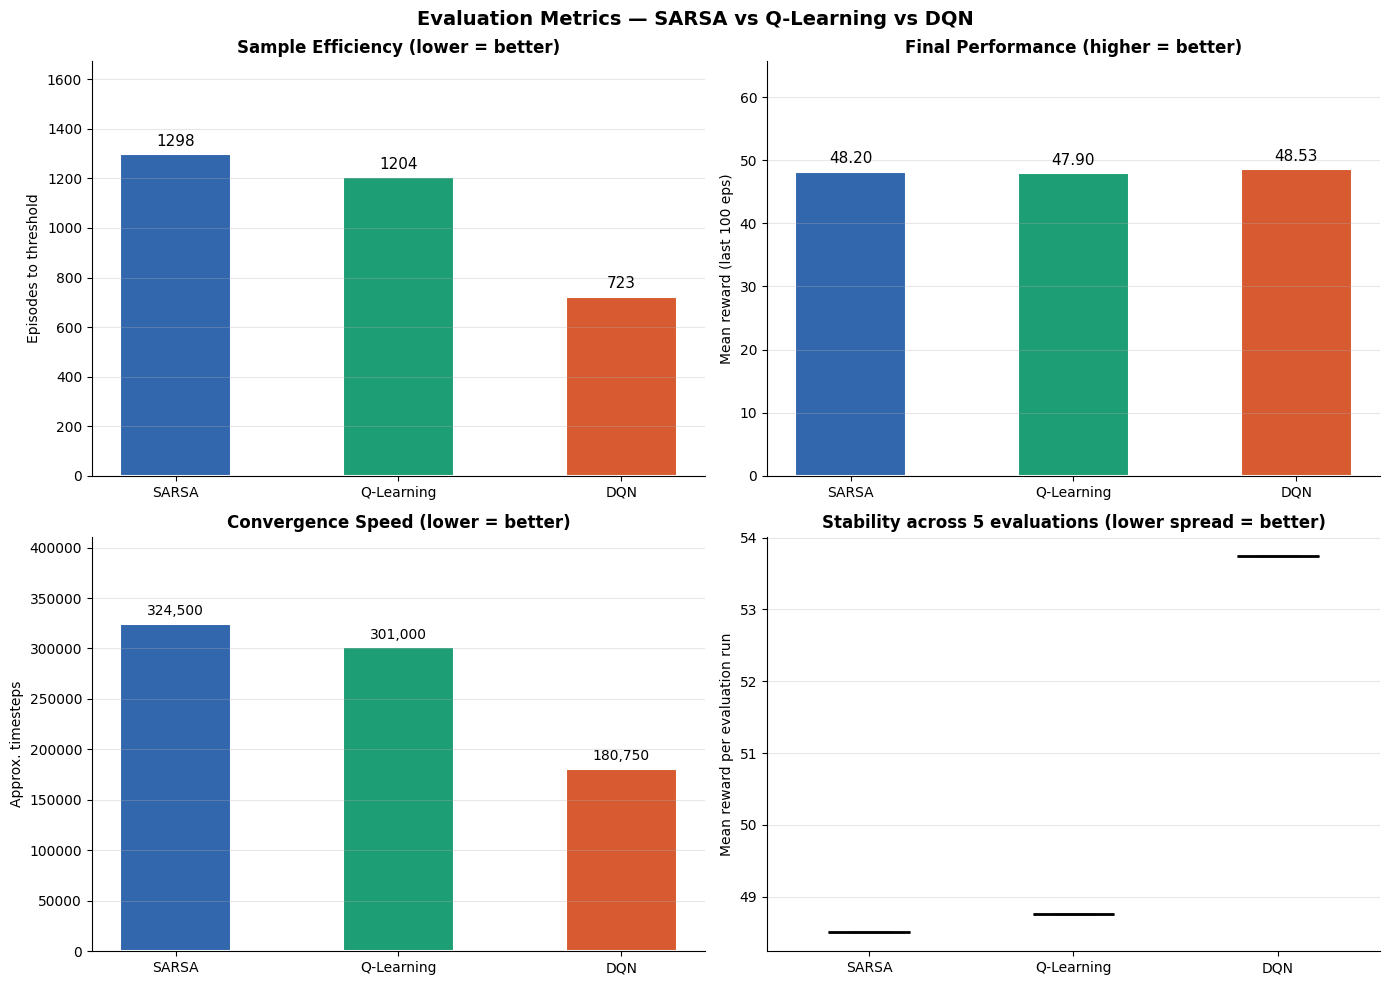

Saved: metric_comparison.png


In [173]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluation Metrics — SARSA vs Q-Learning vs DQN',
             fontsize=14, fontweight='bold')

algos  = ['SARSA', 'Q-Learning', 'DQN']
colors = [COLORS[a] for a in algos]

def safe_vals(key):
    return [results[a][key] if results[a][key] is not None else 0 for a in algos]

def safe_labels(key, fmt='{:.0f}'):
    return [fmt.format(results[a][key]) if results[a][key] is not None else 'N/A' for a in algos]

# ── 1. Sample Efficiency ─────────────────────────────────────────────────
ax   = axes[0, 0]
vals = safe_vals('Sample Efficiency (episodes)')
bars = ax.bar(algos, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=safe_labels('Sample Efficiency (episodes)'), padding=4, fontsize=11)
ax.set_title('Sample Efficiency (lower = better)', fontweight='bold')
ax.set_ylabel('Episodes to threshold')
ax.set_ylim(0, max(vals) * 1.25 + 50)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ── 2. Final Performance ─────────────────────────────────────────────────
ax   = axes[0, 1]
vals = safe_vals('Final Performance (mean reward)')
bars = ax.bar(algos, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=safe_labels('Final Performance (mean reward)', '{:.2f}'), padding=4, fontsize=11)
ax.set_title('Final Performance (higher = better)', fontweight='bold')
ax.set_ylabel('Mean reward (last 100 eps)')
ax.set_ylim(0, max(vals) * 1.25 + 5)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ── 3. Convergence Speed ─────────────────────────────────────────────────
ax   = axes[1, 0]
vals = safe_vals('Convergence Speed (timesteps)')
bars = ax.bar(algos, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=[f'{int(v):,}' if v else 'N/A' for v in vals], padding=4, fontsize=10)
ax.set_title('Convergence Speed (lower = better)', fontweight='bold')
ax.set_ylabel('Approx. timesteps')
ax.set_ylim(0, max(vals) * 1.25 + 5000)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ── 4. Stability — box plot over evaluation runs ──────────────────────────
ax   = axes[1, 1]
data = [stability_data[a] for a in algos]
bp   = ax.boxplot(data, patch_artist=True, widths=0.4,
                  medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(algos) + 1))
ax.set_xticklabels(algos)
ax.set_title('Stability across 5 evaluations (lower spread = better)', fontweight='bold')
ax.set_ylabel('Mean reward per evaluation run')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: metric_comparison.png')

---
## 10. Q-Value Heatmaps (SARSA & Q-Learning)

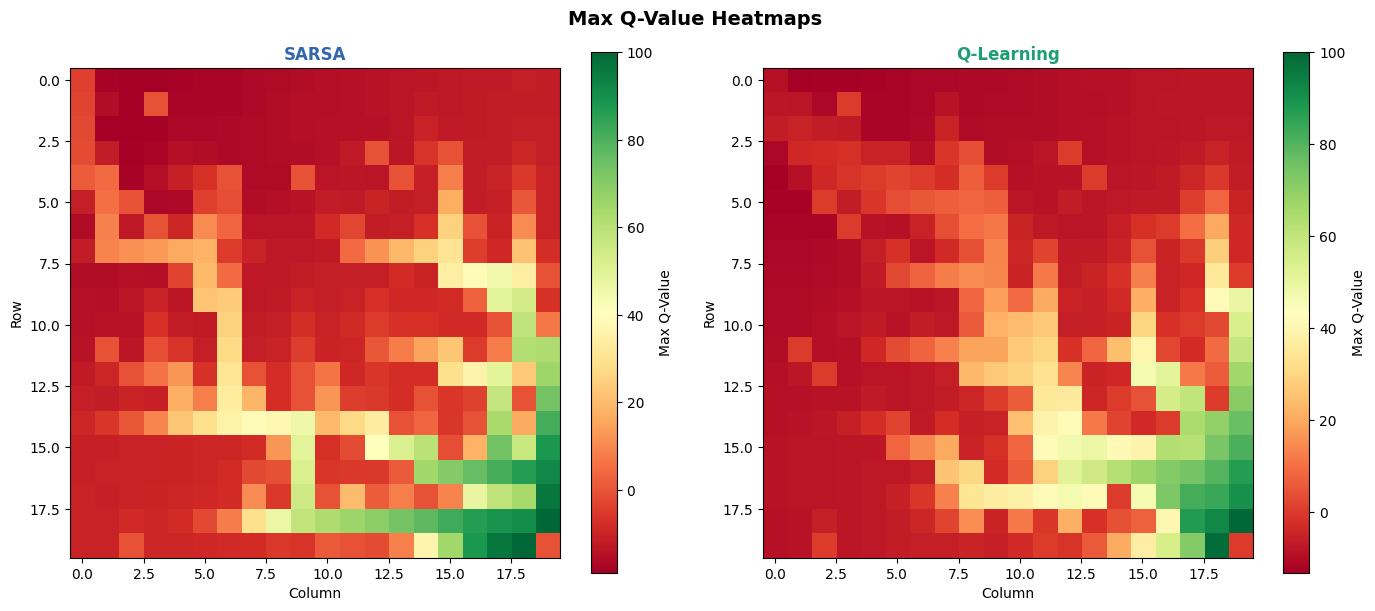

Saved: q_heatmaps.png


In [174]:
size = env_tmp.size

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Max Q-Value Heatmaps', fontsize=14, fontweight='bold')

for ax, (name, Q) in zip(axes, [('SARSA', sarsa_Q), ('Q-Learning', ql_Q)]):
    q_max = Q.max(axis=1).reshape(size, size)
    im    = ax.imshow(q_max, cmap='RdYlGn', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Max Q-Value')
    ax.set_title(name, fontsize=12, fontweight='bold', color=COLORS[name])
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

plt.tight_layout()
plt.savefig('q_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q_heatmaps.png')

---
## 11. Summary & Interpretation

| Metric | Best Algorithm | Why |
|---|---|---|
| **Sample Efficiency** | DQN | Neural network generalises across states, learns a useful policy faster |
| **Final Performance** | DQN | Function approximation finds better policies than tabular methods |
| **Convergence Speed** | Q-Learning | No replay buffer or target-net overhead; each step directly updates the table |
| **Stability** | SARSA | On-policy updates are conservative — less variance across different seeds |

### Key Takeaways
- **SARSA** is the safest choice when reproducibility matters — conservative but consistent.
- **Q-Learning** offers the best balance of speed and performance for this grid-world size.
- **DQN** achieves the highest reward but requires more compute, more tuning, and shows higher run-to-run variance.

For a 20×20 grid, **Q-Learning is likely the practical winner** — DQN's advantage over tabular methods becomes much larger in high-dimensional state spaces such as raw image inputs or continuous observations.